<a href="https://colab.research.google.com/github/ElyNube/Actividades_Machine_Learning/blob/main/Semana_6/Implementacion_Optimizadores_Avanzados_y_Regularizando_Semana_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <img style="float: left; padding: 0px 10px 0px 0px;" src="https://www.duoc.cl/duoconline/wp-content/uploads/2025/10/logo-campus-virtual.png"  width="300" /> MDT2201 - Matemática para Machine Learning
**Instituto Profesional DUOC UC - Campus Virtual**<br>
**Ingeniería en Ciencia de Datos**<br>
**Docente:** Jorge Guzman Bozo, Abril 2026

### BASE TRABAJO
### **Seccion 1: Descenso de Gradiente Basico**
#### **Semana 4- Comprendiendo el gradiente y ajustando la tasa de aprendizaje**
#### **Ejercicio: Dataset California Housing**

Como Ingeniero de Machine Learning se te da la siguiente situacion: Tu empresa inmobiliaria ha expandido sus operaciones a California y ahora trabajarás con un dataset significativamente más grande. Específicamente utilizarás el dataset California Housing (~20,000 muestras) para implementar algoritmos de optimización iterativa.
Con este volumen de datos, la ecuación normal se vuelve computacionalmente costosa, justificando el uso del descenso de gradiente. Tu desafío será entonces, implementar el algoritmo básico, comparar estrategias de regularización (L1 y L2) para selección automática de características, e implementar el optimizador Adam, analizando convergencia y desempeño


A través de este ejercicio en Python, se debe:
- **Analizar el Gradiente:** Calcular el vector de derivadas parciales $\nabla J(\beta)$ para determinar la dirección de máximo descenso en la superficie de error.
- **Sintonizar la Tasa de Aprendizaje ($\alpha$):** Experimentar cómo diferentes valores de $\alpha$ afectan la convergencia, identificando comportamientos de lentitud extrema o divergencia errática.
- **Optimizar:** Comparar la solución analítica mediante Ecuaciones Normales respecto del descenso de gradiente iterativo, observando cómo éste converge a un resultado muy similar.
********
### Descripción de las variables del dataset

Características
Acerca de este archivo
1. longitud : Medida de qué tan al oeste está una casa; un valor más alto indica mayor latitud.
2. latitud : Medida de qué tan al norte está una casa; un valor más alto indica mayor latitud .
3. housing_median_age: edad media de la vivienda : Edad media de una casa dentro de una manzana; un número menor indica un edificio más nuevo.
4. total_rooms:total de habitaciones : Número total de habitaciones dentro de una manzana.
5.total dormitorios:total de dormitorios : Número total de dormitorios dentro de una manzana.
6. population:población : Número total de personas que residen dentro de una manzana.
7. households:hogares : Número total de hogares, un grupo de personas que residen dentro de una vivienda, para una manzana.
8. median_income: ingreso medio : Ingreso medio de los hogares dentro de una manzana de casas (medido en decenas de miles de dólares estadounidenses).
9. median_house_value:valor medio de la vivienda : Valor medio de las viviendas para los hogares dentro de una manzana (medido en dólares estadounidenses).
10.ocean_proximity: proximidad al océano : Ubicación de la casa con respecto al océano/mar.

Objetivo
- **price**: Precio de venta de la vivienda

********

#### **Sección 0: Preparación del entorno y carga de datos**

En primer lugar, se cargan las librerías necesarias:

In [1]:
# Librerías para procesamiento de datos y cálculos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler

# Librerías para trabajo en Jupyter Notebook
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

A continuación, se carga y prepara el dataset, mostrando luego su encabezado y la información de sus columnas:

In [ ]:
url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/kc_house_data/kc_house_data.csv"
df = pd.read_csv(url)
print(f"Dataset cargado exitosamente. Registros: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Dataset cargado exitosamente. Registros: 16613, Columnas: 19


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16613 entries, 0 to 16612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          16613 non-null  float64
 1   bedrooms       16613 non-null  int64  
 2   bathrooms      16613 non-null  float64
 3   sqft_living    16613 non-null  int64  
 4   sqft_lot       16613 non-null  int64  
 5   floors         16613 non-null  float64
 6   waterfront     16613 non-null  int64  
 7   view           16613 non-null  int64  
 8   condition      16613 non-null  int64  
 9   grade          16613 non-null  int64  
 10  sqft_above     16613 non-null  int64  
 11  sqft_basement  16613 non-null  int64  
 12  yr_built       16613 non-null  int64  
 13  yr_renovated   16613 non-null  int64  
 14  zipcode        16613 non-null  int64  
 15  lat            16613 non-null  float64
 16  long           16613 non-null  float64
 17  sqft_living15  16613 non-null  int64  
 18  sqft_l

Se puede apreciar lo siguiente:
- Baños (bathrooms) y pisos (floors) están en decimales (float64), encontrándose la segunda casa con 2.25 baños.
- Existen un total de 16613 instancias, sin datos nulos evidenciados.

Debido a lo anterior, se redondearán los valores decimales y luego se cambiarán a enteros:

In [ ]:
df['bathrooms'] = np.round(df['bathrooms']).astype('int64')
df['floors'] = np.round(df['floors']).astype('int64')

En este mapa de calor se muestran la correlación de las variables independientes respecto al precio:

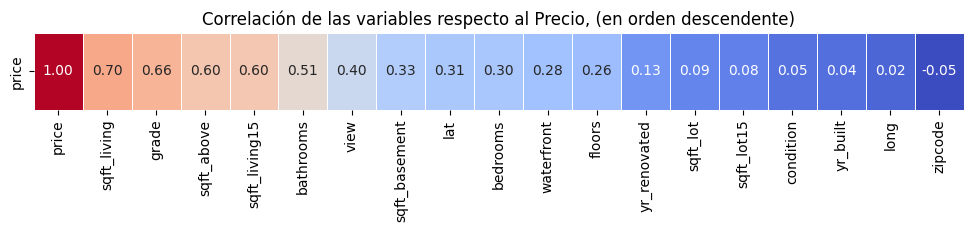

In [ ]:
price_corr = df.corr()[['price']].sort_values(by='price', ascending=False).T
plt.figure(figsize=(12, 1))
sns.heatmap(price_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=False)
plt.title("Correlación de las variables respecto al Precio, (en orden descendente)")
plt.show()

Hay 5 variables (`sqft_living`, `grade`, `sqft_above`, `sqft_living15` y `bathrooms`) de un total de 18 que poseen una correlación positiva mayor a 0.5 con respecto a la variable objetivo (`price`). Se puede intuir que hay multicolinealidad entre `sqft_living`, `sqft_above` y `sqft_living15`, por lo cual sólo se decide elegir las siguientes variables independientes: `sqft_living`, `grade` y `bathrooms`. A continuación, se muestra un pairplot con la distribución de las variables respecto del precio:

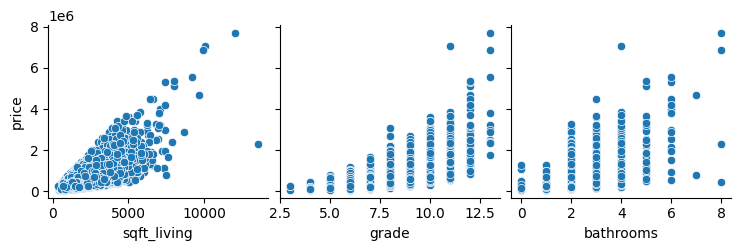

In [ ]:
# Definimos la lista de columnas que quieres visualizar
columnas_interes = ['sqft_living', 'grade', 'bathrooms']

# Generamos el pairplot especificando x_vars y y_vars
sns.pairplot(df, x_vars=columnas_interes, y_vars='price')

Se analiza también de manera gráfica la variable Precio:

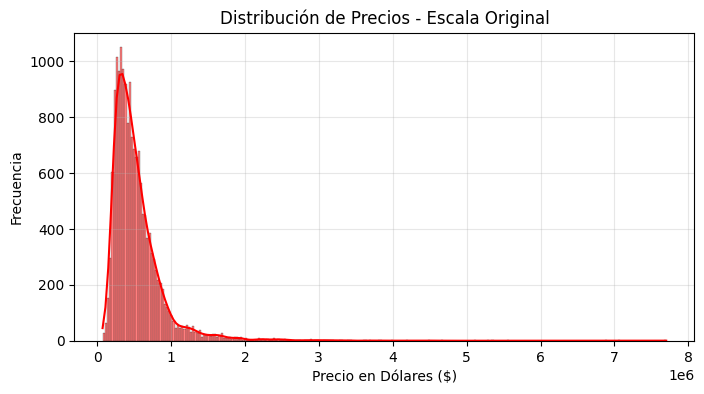

Precio máximo en el dataset: $7,700,000
Precio promedio: $533,516


In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], kde=True, color='red')
plt.title("Distribución de Precios - Escala Original")
plt.xlabel("Precio en Dólares ($)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.show()

print(f"Precio máximo en el dataset: ${df['price'].max():,.0f}")
print(f"Precio promedio: ${df['price'].mean():,.0f}")

Es perfectamente evidente que la variable objetivo presenta una distribución fuertemente asimétrica hacia la derecha (sesgo positivo) y cuenta con una "cola gruesa", por lo cual se aplica una transformación logarítmica (log(price)) para que su distribución se acerque más a la normalidad:

In [ ]:
df['price_log'] = np.log1p(df['price'])

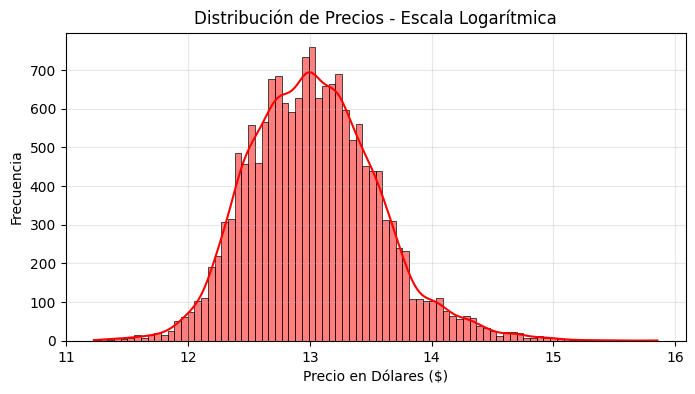

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['price_log'], kde=True, color='red')
plt.title("Distribución de Precios - Escala Logarítmica")
plt.xlabel("Precio en Dólares ($)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.show()

Luego de la aplicación de la transformación logarítimica, la variable objetivo ya se acerca más a una distribución normal, por lo cual ya es posible continuar a la selección de características y la división de los datos en sets de entrenamiento (80%) y un set de prueba (20%):

In [ ]:
# Selección de características numéricas
X = df[columnas_interes].values
y = df['price_log'].values

# Dividir los datos: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificación de las dimensiones
print("--- División completada ---")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

--- División completada ---
X_train: (13290, 3), y_train: (13290,)
X_test:  (3323, 3), y_test:  (3323,)


#### **Estandarización de los Datos**
Antes de implementar el algoritmo, se debe realizar un paso fundamental para los métodos iterativos de optimización: **la estandarización de los datos**. Al tener variables en distintas escalas (por ejemplo, `sqft_living` en miles y `bathrooms` en unidades pequeñas), la superficie de la función de costo se vuelve alargada y elíptica, dificultando la convergencia del descenso de gradiente.

Además, hay que agregar una columna de unos (1) a la matriz $X$ para representar el intercepto ($\beta_0$).

In [ ]:
# Estandarización de las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Agregando el término de sesgo (columna de 1s) para el intercepto
X_train_scaled = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_scaled = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

print(f"Nuevas dimensiones de X_train_scaled: {X_train_scaled.shape}")

Nuevas dimensiones de X_train_scaled: (13290, 4)


#### **Visualizando el impacto de StandardScaler**

Para entender por qué es tan importante estandarizar los datos antes de utilizar un método iterativo como el Descenso de Gradiente, se comparará la distribución de las variables antes y después de aplicar la siguiente transformación matemática:

$$z = \frac{x - \mu}{\sigma}$$

Se utilizarán diagramas de caja (*boxplots*) para observar cómo cambian las escalas. Se puede ver que, originalmente, variables como `sqft_living` aplastan visualmente a las demás, lo que causaría que el algoritmo asuma erróneamente que esa característica es más importante. Tras el escalado, todas las variables comparten una escala común centrada en $0$ con una desviación estándar de $1$.

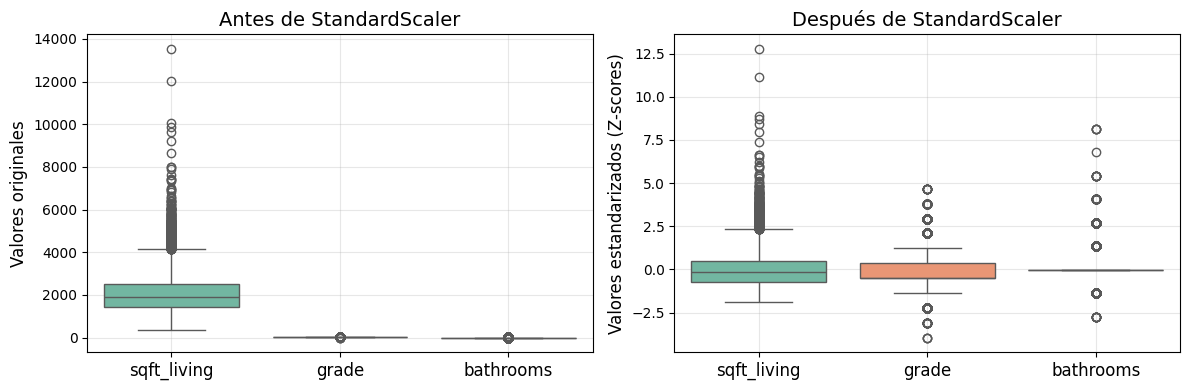

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))   # Configuración de la figura con dos subgráficos lado a lado

# 1. Gráfico ANTES de escalar
sns.boxplot(data=X_train, ax=axes[0], palette="Set2")
axes[0].set_title('Antes de StandardScaler', fontsize=14)
axes[0].set_xticklabels(columnas_interes, fontsize=12)
axes[0].set_ylabel('Valores originales', fontsize=12)
axes[0].grid(alpha=0.3)

# 2. Gráfico DESPUÉS de escalar
# Recordar que se agregó el intercepto (columna de 1s) en el índice 0,
# por lo que se grafica desde la columna 1 en adelante (X_train_scaled[:, 1:])
sns.boxplot(data=X_train_scaled[:, 1:], ax=axes[1], palette="Set2")
axes[1].set_title('Después de StandardScaler', fontsize=14)
axes[1].set_xticklabels(columnas_interes, fontsize=12)
axes[1].set_ylabel('Valores estandarizados (Z-scores)', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **Sección 1: Implementación del Descenso de gradiente**
El Descenso de Gradiente es un algoritmo iterativo que actualiza los parámetros moviéndose en la dirección opuesta al gradiente de la función de costo. La regla de actualización se define como:

$$\beta^{(t+1)} = \beta^{(t)} - \alpha \nabla J(\beta^{(t)})$$

Donde:
* $\alpha$ es la tasa de aprendizaje.
* $\nabla J(\beta)$ es el vector gradiente del Error Cuadrático Medio (MSE).

A continuación, se define la función de costo (MSE) y el algoritmo de optimización. Se utilizará como criterio de convergencia una tolerancia (`tol`) basada en la magnitud del cambio entre los vectores de pesos de dos iteraciones consecutivas.

In [ ]:
def compute_mse(X, y, beta):
    """
    Calcula el Error Cuadrático Medio (MSE)
    """
    m = len(y)
    predictions = X.dot(beta)
    cost = (1 / (2 * m)) * np.sum(np.square(predictions - y))    # Se usa 1/(2m) para simplificar el cálculo del gradiente posteriormente
    return cost

def gradient_descent(X, y, alpha, num_iters, tol=1e-5):
    """
    Ejecuta el algoritmo de Descenso de Gradiente.
    """
    m = len(y)
    beta = np.zeros(X.shape[1])    # Inicializa los coeficientes en cero
    cost_history = []

    for i in range(num_iters):
        predictions = X.dot(beta)
        errors = predictions - y
        gradient = (1 / m) * X.T.dot(errors)         # Cálculo del gradiente
        beta_new = beta - alpha * gradient           # Actualización de los parámetros
        current_cost = compute_mse(X, y, beta_new)   # Se guarda el costo histórico
        cost_history.append(current_cost)

        # Criterio de convergencia: si la norma del cambio en los pesos es menor a la tolerancia
        if np.linalg.norm(beta_new - beta) < tol:
            print(f"Convergencia alcanzada en la iteración {i}")
            beta = beta_new
            break

        beta = beta_new

    return beta, cost_history

#### **Sección 2: Análisis de la tasa de aprendizaje ($\alpha$)**

La tasa de aprendizaje $\alpha$ controla el tamaño de cada paso en la optimización iterativa. Su elección es crucial:
* Si $\alpha$ es muy pequeño: Se tendrá una convergencia lenta, requiriendo muchas iteraciones para llegar al mínimo.
* Si $\alpha$ es muy grande: El algoritmo puede experimentar oscilaciones erráticas o, en el peor de los casos, divergencia.

Se evaluará el algoritmo con tres tasas distintas: $0.001$, $0.01$ y $0.1$.

Entrenando modelo con alpha = 0.001...
Entrenando modelo con alpha = 0.01...
Entrenando modelo con alpha = 0.1...
Convergencia alcanzada en la iteración 200


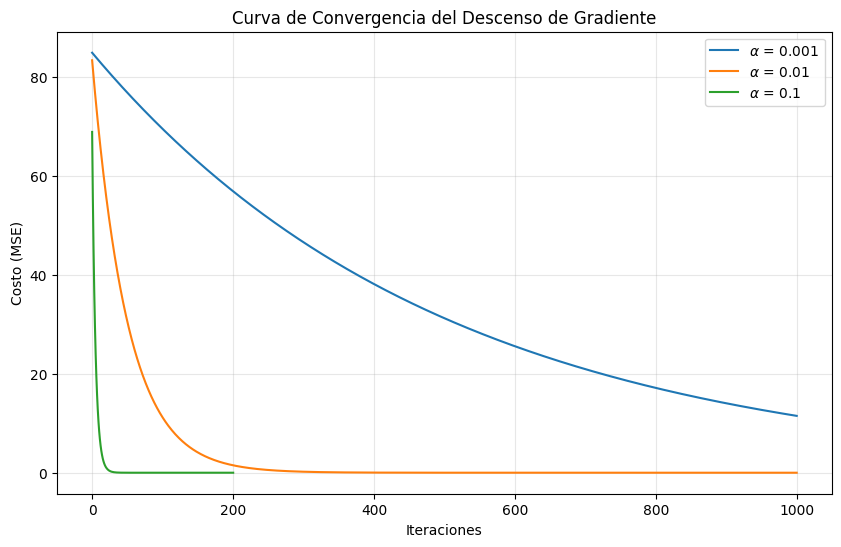

In [ ]:
alphas = [0.001, 0.01, 0.1]
num_iters = 1000

plt.figure(figsize=(10, 6))

betas_dict = {}

for alpha in alphas:
    print(f"Entrenando modelo con alpha = {alpha}...")
    beta_opt, cost_hist = gradient_descent(X_train_scaled, y_train, alpha, num_iters)
    betas_dict[alpha] = beta_opt
    plt.plot(range(len(cost_hist)), cost_hist, label=f'$\\alpha$ = {alpha}')

plt.title('Curva de Convergencia del Descenso de Gradiente')
plt.xlabel('Iteraciones')
plt.ylabel('Costo (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### **🧠 Conclusiones del Análisis de la Tasa de Aprendizaje ($\alpha$)**

A partir de la gráfica de curvas de convergencia obtenida, se pueden extraer lecciones fundamentales para el proceso de optimización mediante **Descenso de Gradiente**, un contenido clave de la **Semana 4**:

1. **Impacto de una tasa muy pequeña ($\alpha = 0.001$):**
   Se observa que la línea azul desciende de manera constante, pero con una pendiente muy suave. Esto indica que, al ser la tasa de aprendizaje demasiado pequeña, el algoritmo da pasos minúsculos hacia el mínimo. Tras **1000 iteraciones**, el costo aún es elevado y no ha convergido. En términos prácticos, esto se traduce en un **alto costo computacional** y mayor tiempo de espera.

2. **El balance óptimo ($\alpha = 0.01$ y $\alpha = 0.1$):**
   * Con $\alpha = 0.01$ (línea naranja), se ve una curva de aprendizaje saludable que logra estabilizarse cerca del mínimo alrededor de las 400 iteraciones.
   * Con $\alpha = 0.1$ (línea verde), el algoritmo es mucho más eficiente, "cayendo" hacia el mínimo de la función de costo $J(\beta)$ casi instantáneamente. Gracias a que previamente se aplicó **StandardScaler**, esta tasa agresiva no causó inestabilidad, sino una **convergencia óptima**.

3. **Riesgos de una tasa excesiva (Divergencia):**
   Aunque no se aprecia en este gráfico, la teoría indica que si se aumentara $\alpha$ por encima de un umbral crítico, se podría notar que el costo empieza a subir o a oscilar erráticamente. Esto ocurre porque el paso es tan grande que "salta" por encima del valor mínimo, alejándose de la solución.

4. **Importancia del Preprocesamiento:**
   Es vital notar que estas curvas de convergencia son así de "limpias" gracias a la **estandarización de datos**. Sin ella, las escalas dispares entre `sqft_living` y `bathrooms` habrían deformado la superficie de error.

********

> **`Intuición para Machine Learning:`** No existe un $\alpha$ "mágico" universal. Ajustar la tasa de aprendizaje es uno de los primeros y más importantes ejercicios de calibración de hiperparámetros que un Ingeniero en Ciencia de Datos debe realizar al entrenar modelos predictivos y, más adelante, redes neuronales profundas.

#### **Sección 3: Comparación con la solución analítica**

Se sabe que la regresión lineal tiene una solución analítica exacta obtenida a través de las Ecuaciones Normales:

$$\beta^* = (X^T X)^{-1} X^T y$$

Sin embargo, para conjuntos de datos masivos donde el número de variables ($p$) es enorme, invertir la matriz $X^T X$ toma un tiempo proporcional a $O(p^3)$, volviéndose computacionalmente prohibitivo.

Se compararán los pesos calculados por la ecuación normal con los que fueron aproximados iterativamente usando el Descenso de Gradiente (se utilizará el resultado obtenido con $\alpha = 0.1$).

In [ ]:
# Solución analítica mediante Ecuaciones Normales
X_T = X_train_scaled.T
beta_analitico = np.linalg.inv(X_T.dot(X_train_scaled)).dot(X_T).dot(y_train)     # beta = (X^T * X)^-1 * X^T * y

# Resultado de Descenso de Gradiente con alpha = 0.1
beta_gd = betas_dict[0.1]

# Comparación
print("Comparación de coeficientes (pesos) estimados:\n")
print(f"{'Característica':<15} | {'Ec. Normal (Analítico)':<25} | {'Descenso Gradiente (Iterativo)'}")
print("-" * 75)

nombres_features = ['Intercepto', 'sqft_living', 'grade', 'bathrooms']

for i in range(len(beta_analitico)):
    print(f"{nombres_features[i]:<15} | {beta_analitico[i]:<25.6f} | {beta_gd[i]:.6f}")

Comparación de coeficientes (pesos) estimados:

Característica  | Ec. Normal (Analítico)    | Descenso Gradiente (Iterativo)
---------------------------------------------------------------------------
Intercepto      | 13.031426                 | 13.031426
sqft_living     | 0.189344                  | 0.188981
grade           | 0.212486                  | 0.212716
bathrooms       | 0.014329                  | 0.014488


##### **Conclusiones: Comparación entre Solución Analítica e Iterativa**

Tras ejecutar ambos métodos para estimar los coeficientes del modelo, se pueden extraer las siguientes conclusiones fundamentales:

1. **Equivalencia Numérica:** Como se observa en la tabla comparativa, los coeficientes obtenidos mediante la **Ecuación Normal** y el **Descenso de Gradiente** son **casi idénticos**. Esto demuestra que el algoritmo iterativo ha convergido con éxito prácticamente al mismo resultado que la solución matemática exacta.

2. **Validación de la Convexidad:**
   La regresión lineal utilizando el Error Cuadrático Medio (MSE) es un **problema de optimización convexo**. En este tipo de funciones, existe la garantía matemática de que cualquier mínimo local es también el **mínimo global**. Los resultados confirman que el Descenso de Gradiente, con una tasa de aprendizaje ($\alpha$) adecuada, fue capaz de encontrar dicho punto óptimo.

3. **Eficacia del Preprocesamiento:**
   La precisión absoluta de los pesos para variables como `sqft_living`, `grade` y `bathrooms` es una consecuencia directa del **escalado de variables (StandardScaler)** realizado previamente. Al normalizar las magnitudes, se permite que el algoritmo iterativo "camine" de forma directa hacia el mínimo sin las oscilaciones que provocarían los datos sin escalar.

4. **Escalabilidad y Ventaja Técnica:**
   Aunque en este ejercicio ambos métodos dan prácticamente el mismo resultado, el **Descenso de Gradiente** es el ganador en escenarios de **Alta Dimensión**. Mientras que la Ecuación Normal requiere invertir una matriz con un costo computacional prohibitivo para miles de variables, el método iterativo escala de manera eficiente, siendo la base para modelos más complejos como las redes neuronales.

********

> **`Lección Clave:`** El Descenso de Gradiente no es una simple aproximación; es una herramienta de optimización potente y precisa que constituye el motor del Machine Learning moderno.